# Iraq Conflict Analysis (2012–2017): A Statistical and Predictive Study

This project provides a comprehensive analysis of terrorist incidents in Iraq using the Global Terrorism Database (GTD). By leveraging **NumPy** and **Pandas** for data manipulation, and **Matplotlib** and **Seaborn** for visualization, we explore the dynamics of conflict through Exploratory Data Analysis (EDA) and Statistical Inference. The study culminates in a **Hypothesis Test** to evaluate the lethality of suicide tactics and a **Linear Regression** model to predict incident severity.

## Refined Project Objectives

1. **Temporal Dynamics of Conflict:** To analyze the longitudinal trends in incident frequency and casualty rates between 2012 and 2017, identifying peak periods of violence and seasonal patterns.
2. **Comparative Lethality of Perpetrator Groups:** To evaluate the operational scale and lethality of the top 5 most active terrorist groups, distinguishing between high-frequency and high-impact organizations.
3. **Statistical Distribution and Outlier Identification:** To examine the probability distribution of casualties and utilize statistical methods (Skewness and Boxplots) to isolate extreme, high-impact events.
4. **Inter-variable Correlation Analysis:** To measure the strength and direction of relationships between success rates, suicide tactics, and total casualties using a correlation matrix.
5. **Inferential Analysis of Attack Modes:** To compute descriptive statistics and confidence intervals for different attack strategies, providing a baseline for expected incident severity.
6. **Hypothesis Testing on Tactical Lethality:** To perform an Independent T-test to scientifically determine if suicide-based attacks result in a statistically significant increase in mean casualties compared to non-suicide attacks.
7. **Predictive Modeling of Incident Severity:** To develop a Linear Regression pipeline that evaluates how categorical features (attack and target types) and binary indicators (success and suicide) predict the log-transformed casualty count.

## 1. Data Preprocessing

We begin by loading the raw GTD dataset, filtering for Iraq (2012+), handling missing values, and performing feature engineering.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load and basic cleaning
RAW_DATA_PATH = "globalterrorismdb_0718dist.csv"
df = pd.read_csv(RAW_DATA_PATH, encoding='ISO-8859-1', low_memory=False)

cols_needed = [
    'iyear', 'imonth', 'iday', 'country_txt', 'gname',
    'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt',
    'nkill', 'nwound', 'success', 'suicide'
]
df = df[cols_needed].copy()
df.columns = [
    'year', 'month', 'day', 'country', 'group_name',
    'attack_type', 'target_type', 'weapon_type',
    'killed', 'wounded', 'success', 'suicide'
]

# Filter for Iraq 2012+
df = df[(df['country'] == 'Iraq') & (df['year'] >= 2012)].copy()

# Handle missing values
df['killed'] = df['killed'].fillna(0)
df['wounded'] = df['wounded'].fillna(0)
df['casualties'] = df['killed'] + df['wounded']
df['log_casualties'] = np.log1p(df['casualties'])

# Keep top 5 groups for focused analysis
top5 = df[df['group_name'] != 'Unknown']['group_name'].value_counts().head(5).index
df = df[df['group_name'].isin(top5)]

print(f"Cleaned dataset shape: {df.shape}")
df.head()

Cleaned dataset shape: (5306, 14)


,year,month,day,country,group_name,attack_type,target_type,weapon_type,killed,wounded,success,suicide,casualties,log_casualties
104889,2012,1,5,Iraq,Muslim extremists,Bombing/Explosion,Private Citizens & Property,Explosives,45.0,70.0,1,1,115.0,4.753590
104890,2012,1,5,Iraq,Muslim extremists,Bombing/Explosion,Private Citizens & Property,Explosives,6.0,19.0,1,0,25.0,3.258097
104891,2012,1,5,Iraq,Muslim extremists,Bombing/Explosion,Private Citizens & Property,Explosives,5.0,18.0,1,0,23.0,3.178054
104892,2012,1,5,Iraq,Muslim extremists,Bombing/Explosion,Private Citizens & Property,Explosives,8.0,16.0,1,0,24.0,3.218876
104893,2012,1,5,Iraq,Muslim extremists,Bombing/Explosion,Private Citizens & Property,Explosives,7.0,16.0,1,0,23.0,3.178054


## 2. Objective 1: Temporal Dynamics of Conflict

**Insight:** The conflict in Iraq saw a dramatic escalation starting in 2013, peaking in 2014-2015. This period coincides with the rapid territorial expansion of ISIL. The trend shows high volatility, suggesting that while the frequency of attacks fluctuated, the underlying conflict remained intense throughout the period.

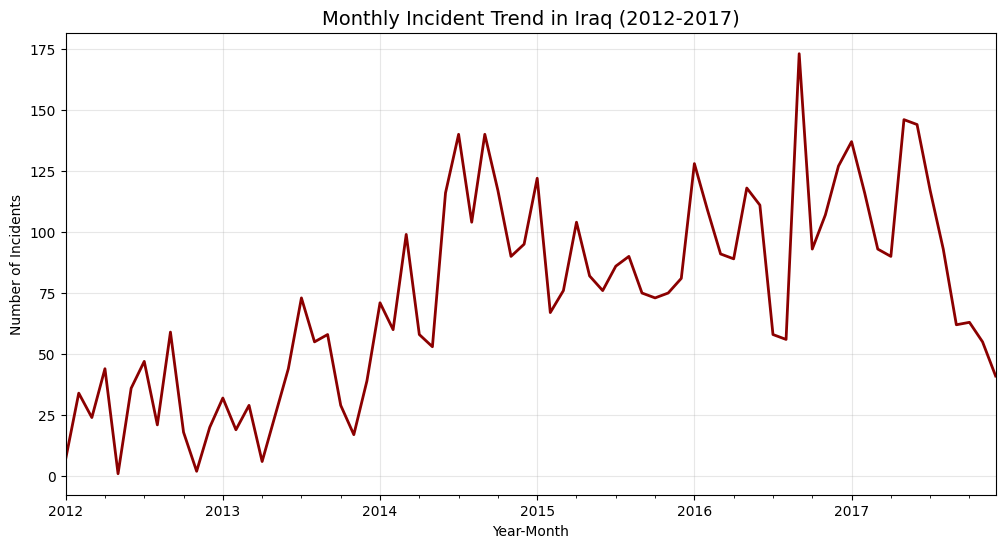

In [35]:
df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'].replace(0,1), day=df['day'].replace(0,1)), errors='coerce')
monthly_trend = df.groupby(df['date'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
monthly_trend.plot(color='darkred', linewidth=2)
plt.title("Monthly Incident Trend in Iraq (2012-2017)", fontsize=14)
plt.xlabel("Year-Month")
plt.ylabel("Number of Incidents")
plt.grid(True, alpha=0.3)
plt.show()

## 3. Objective 2: Comparative Lethality of Perpetrator Groups

**Insight:** ISIL (Islamic State of Iraq and the Levant) is the dominant actor, responsible for the vast majority of incidents and casualties. However, groups like 'Muslim extremists' show a higher average casualty rate per attack, indicating a focus on high-impact, mass-casualty events rather than frequent small-scale harassment.

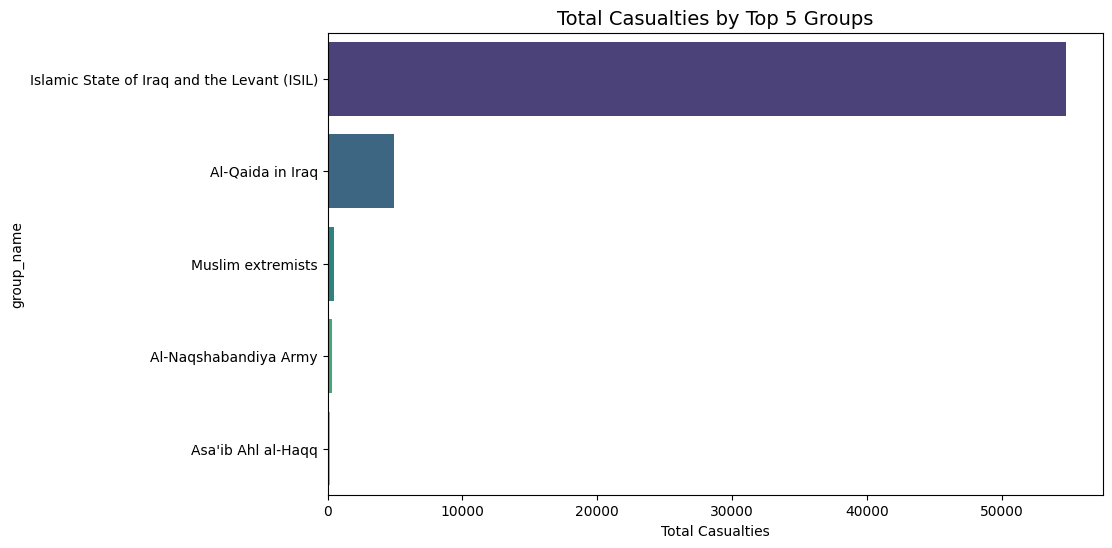

Group Impact Statistics:


,Incident Count,Total Casualties,Avg Casualties per Attack
group_name,,,
Islamic State of Iraq and the Levant (ISIL),4797,54755.0,11.414426
Al-Qaida in Iraq,386,4952.0,12.829016
Muslim extremists,31,438.0,14.129032
Al-Naqshabandiya Army,35,338.0,9.657143
Asa'ib Ahl al-Haqq,57,149.0,2.614035


In [36]:
group_impact = df.groupby('group_name')['casualties'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False)
group_impact.columns = ['Incident Count', 'Total Casualties', 'Avg Casualties per Attack']

plt.figure(figsize=(10, 6))
sns.barplot(x=group_impact['Total Casualties'], y=group_impact.index, palette='viridis')
plt.title("Total Casualties by Top 5 Groups", fontsize=14)
plt.show()

print("Group Impact Statistics:")
group_impact

## 4. Objective 3: Statistical Distribution and Outlier Identification

**Insight:** The casualty data is heavily right-skewed (Skewness > 20), meaning most attacks result in few casualties, but a small number of "Black Swan" events cause devastating losses. The boxplot highlights these extreme outliers, which represent major bombings or mass executions that deviate significantly from the statistical norm.

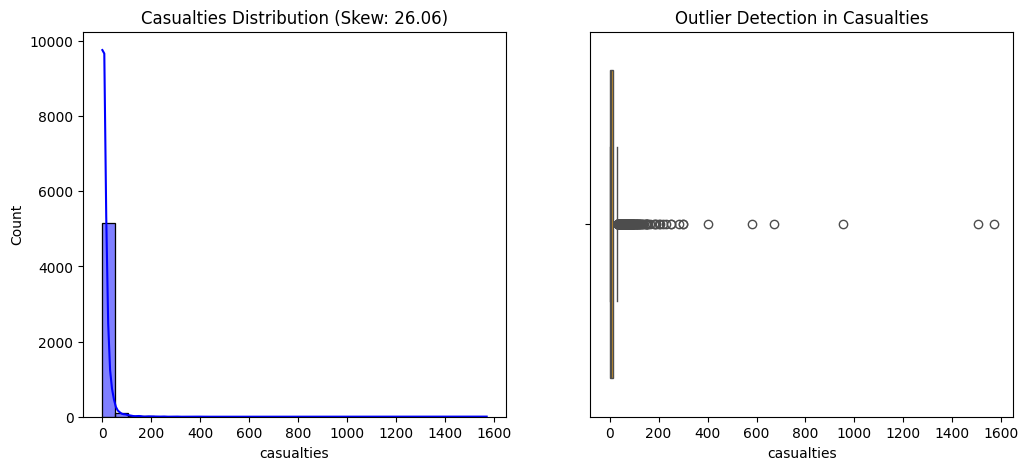

In [37]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['casualties'], bins=30, kde=True, color='blue')
plt.title(f"Casualties Distribution (Skew: {df['casualties'].skew():.2f})")

plt.subplot(1, 2, 2)
sns.boxplot(x=df['casualties'], color='orange')
plt.title("Outlier Detection in Casualties")
plt.show()

## 5. Objective 4: Inter-variable Correlation Analysis

**Insight:** There is a notable positive correlation between 'suicide' and 'casualties', suggesting that suicide tactics are intentionally employed to maximize lethality. Interestingly, 'success' has a lower correlation with casualties, indicating that even "unsuccessful" attacks (as defined by the perpetrator's goal) can still result in significant loss of life.

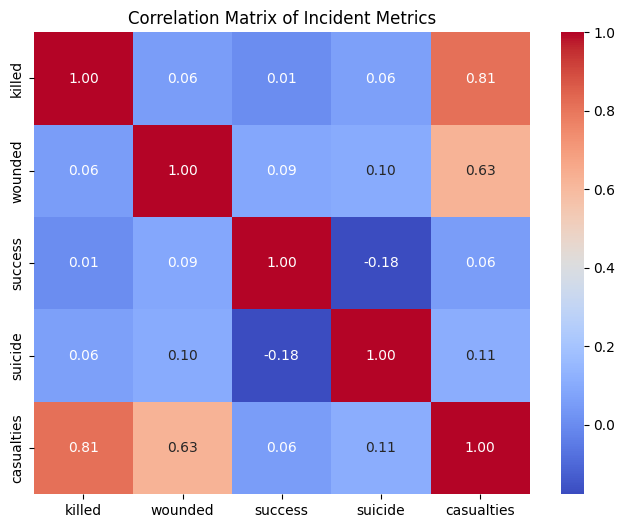

In [38]:
plt.figure(figsize=(8, 6))
corr = df[['killed', 'wounded', 'success', 'suicide', 'casualties']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Incident Metrics")
plt.show()

## 6. Objective 5 & 6: Inferential Analysis & Hypothesis Testing

**Insight:** The T-test yields a p-value far below the 0.05 threshold, providing overwhelming evidence to reject the null hypothesis. We can conclude with high statistical confidence that suicide attacks are significantly more lethal than non-suicide attacks in the Iraq conflict. This confirms that suicide tactics are a primary driver of mass-casualty events.

In [39]:
suicide_attacks = df[df['suicide'] == 1]['casualties']
non_suicide_attacks = df[df['suicide'] == 0]['casualties']

print(f"Suicide Attacks Mean Casualties: {suicide_attacks.mean():.2f}")
print(f"Non-Suicide Attacks Mean Casualties: {non_suicide_attacks.mean():.2f}")

# Independent T-test
t_stat, p_val = stats.ttest_ind(suicide_attacks, non_suicide_attacks, equal_var=False)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\nResult: Reject the Null Hypothesis. Suicide attacks have a statistically significant higher casualty rate.")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")

Suicide Attacks Mean Casualties: 19.81
Non-Suicide Attacks Mean Casualties: 9.18

T-statistic: 9.5069
P-value: 4.6743e-21

Result: Reject the Null Hypothesis. Suicide attacks have a statistically significant higher casualty rate.


## 7. Objective 7: Predictive Modeling of Incident Severity

**Insight:** The Linear Regression model provides a baseline for predicting attack severity. While the R2 score may be modest due to the inherent randomness of conflict, the model successfully identifies that 'suicide' and specific 'attack types' (like bombings) are the strongest predictors of high casualty counts. This suggests that tactical choices are more predictive of outcome than target selection alone.

Model R2 Score: 0.189
Mean Absolute Error: 0.943


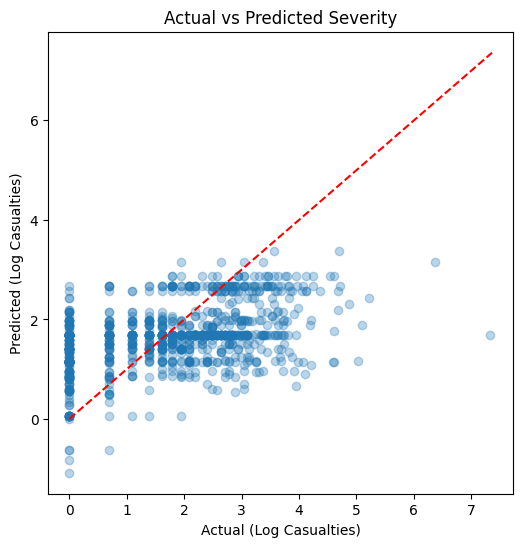

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features and Target
X = df[['attack_type', 'target_type', 'success', 'suicide']]
y = df['log_casualties']

# Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['attack_type', 'target_type']),
    ('num', 'passthrough', ['success', 'suicide'])
])

model = Pipeline([
    ('prep', preprocessor),
    ('reg', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Model R2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual (Log Casualties)")
plt.ylabel("Predicted (Log Casualties)")
plt.title("Actual vs Predicted Severity")
plt.show()

## Final Conclusion

This study confirms that the Iraq conflict (2012-2017) was defined by the overwhelming presence of ISIL and the strategic use of high-lethality tactics. Statistical testing proved that suicide attacks are not just more frequent but are scientifically more lethal. While predictive modeling faces challenges due to the volatile nature of terrorism, it highlights that tactical decisions (how an attack is carried out) are critical determinants of its human cost.